# VTaC Utility Evaluation — True Vanilla CVAE Fixed

**Question:** Does synthetic data improve downstream VT alarm classification performance?

Training settings:
1. Real-only
2. Real + SMOTE
3. Real + True Vanilla CVAE
4. Real + Proposed CVAE

Downstream classifiers:
1. CNN1D
2. FCN

Metrics:
- AUPRC
- AUROC
- Best-F1
- Precision
- Recall / Sensitivity

Important fix:
- The `Vanilla CVAE` row must point to `outputs/true_vanilla_cvae/generated_true_true_vanilla.pt`.
- The notebook intentionally does **not** auto-select old `generated_true_v4.pt` / corr-loss / phys-loss files as vanilla.


In [1]:
# ============================================================
# 0. Drive mount + imports
# ============================================================

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Drive mount skipped:", e)

import os
import json
import glob
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    confusion_matrix,
    balanced_accuracy_score,
)

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

Mounted at /content/drive
device: cuda


In [2]:
# ============================================================
# 1. Config
# ============================================================

# Single-seed quick check:
# EVAL_SEEDS = [42]

# For report-level repeated-seed evaluation, use:
EVAL_SEEDS = [0, 1, 2, 3, 4]

EPOCHS = 40
PATIENCE = 8
BATCH_SIZE = 64
EVAL_BATCH_SIZE = 128
LR = 3e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2

PROJECT_DRIVE = "/content/drive/MyDrive/vtac_project"
EVAL_MANIFEST_PATH = f"{PROJECT_DRIVE}/evaluation/eval_manifest.json"

# Use the same real-data directory convention as the true vanilla sampling notebook.
REAL_DATA_DIR_CANDIDATES = [
    f"{PROJECT_DRIVE}/data/processed",
    "/content/drive/MyDrive/vtac_preprocessed_10s_v2",
]

def first_existing_dir(paths):
    for p in paths:
        if os.path.isdir(p):
            return p
    return paths[0]

REAL_DATA_DIR = first_existing_dir(REAL_DATA_DIR_CANDIDATES)

TRUE_VANILLA_SYN_PATH = f"{PROJECT_DRIVE}/outputs/true_vanilla_cvae/generated_true_true_vanilla.pt"
PROPOSED_SYN_FALLBACK_PATH = f"{PROJECT_DRIVE}/outputs/cvae_v4_classifier_physloss/generated_true_v4_classifier_physloss.pt"

# Keep this run separate from old utility eval outputs.
EVAL_OUT_DIR = f"{PROJECT_DRIVE}/evaluation_true_vanilla"
os.makedirs(EVAL_OUT_DIR, exist_ok=True)

FALLBACK_CFG = {
    "real_data": {
        "train": f"{REAL_DATA_DIR}/train_10s.pt",
        "val": f"{REAL_DATA_DIR}/val_10s.pt",
        "test": f"{REAL_DATA_DIR}/test_10s.pt",
    },
    "synthetic_data": {
        "vanilla_cvae": TRUE_VANILLA_SYN_PATH,
        "proposed_classifier_physloss_cvae": PROPOSED_SYN_FALLBACK_PATH,
    },
    "evaluation_output_dir": EVAL_OUT_DIR,
    "channels": ["ECG1", "ECG2", "PPG", "ABP"],
    "window_sec": [-10, 0],
    "fs": 250,
}

# Load manifest only for proposed path convenience, then force the corrected real/vanilla/eval paths.
if os.path.exists(EVAL_MANIFEST_PATH):
    with open(EVAL_MANIFEST_PATH, "r") as f:
        cfg = json.load(f)
    print("Loaded manifest:", EVAL_MANIFEST_PATH)
else:
    cfg = {}
    print("Manifest not found. Using fixed fallback config.")

cfg.setdefault("synthetic_data", {})

# Force these to avoid accidentally evaluating the old non-vanilla file.
cfg["real_data"] = FALLBACK_CFG["real_data"]
cfg["synthetic_data"]["vanilla_cvae"] = TRUE_VANILLA_SYN_PATH
cfg["synthetic_data"].setdefault("proposed_classifier_physloss_cvae", PROPOSED_SYN_FALLBACK_PATH)
cfg["evaluation_output_dir"] = EVAL_OUT_DIR
cfg.setdefault("channels", FALLBACK_CFG["channels"])
cfg.setdefault("window_sec", FALLBACK_CFG["window_sec"])
cfg.setdefault("fs", 250)

print(json.dumps(cfg, indent=2))
print("REAL_DATA_DIR:", REAL_DATA_DIR)
print("EVAL_OUT_DIR:", EVAL_OUT_DIR)


Loaded manifest: /content/drive/MyDrive/vtac_project/evaluation/eval_manifest.json
{
  "real_data": {
    "train": "/content/drive/MyDrive/vtac_project/data/processed/train_10s.pt",
    "val": "/content/drive/MyDrive/vtac_project/data/processed/val_10s.pt",
    "test": "/content/drive/MyDrive/vtac_project/data/processed/test_10s.pt"
  },
  "synthetic_data": {
    "vanilla_cvae": "/content/drive/MyDrive/vtac_project/outputs/true_vanilla_cvae/generated_true_true_vanilla.pt",
    "proposed_classifier_physloss_cvae": "/content/drive/MyDrive/vtac_project/outputs/cvae_v4_classifier_physloss/generated_true_v4_classifier_physloss.pt"
  },
  "checkpoints": {
    "proposed_classifier_physloss_cvae": "/content/drive/MyDrive/vtac_project/outputs/cvae_v4_classifier_physloss/cvae_v4_classifier_physloss_best.pt"
  },
  "evaluation_output_dir": "/content/drive/MyDrive/vtac_project/evaluation_true_vanilla",
  "channels": [
    "ECG1",
    "ECG2",
    "PPG",
    "ABP"
  ],
  "window_sec": [
    -10,
   

In [3]:
# ============================================================
# 2. Verify paths: do not auto-pick old vanilla files
# ============================================================

prop_path = cfg["synthetic_data"].get(
    "proposed_classifier_physloss_cvae",
    PROPOSED_SYN_FALLBACK_PATH,
)
vanilla_path = TRUE_VANILLA_SYN_PATH

cfg["synthetic_data"]["vanilla_cvae"] = vanilla_path
cfg["synthetic_data"]["proposed_classifier_physloss_cvae"] = prop_path

paths_to_check = {
    "train": cfg["real_data"]["train"],
    "val": cfg["real_data"]["val"],
    "test": cfg["real_data"]["test"],
    "true_vanilla_cvae": cfg["synthetic_data"]["vanilla_cvae"],
    "proposed_classifier_physloss_cvae": cfg["synthetic_data"]["proposed_classifier_physloss_cvae"],
}

print("\nPath check:")
for name, path in paths_to_check.items():
    print(f"{name:35s} exists={os.path.exists(path) if path is not None else False} | {path}")

assert os.path.exists(cfg["real_data"]["train"]), "Missing train data"
assert os.path.exists(cfg["real_data"]["val"]), "Missing val data"
assert os.path.exists(cfg["real_data"]["test"]), "Missing test data"
assert os.path.exists(cfg["synthetic_data"]["vanilla_cvae"]), (
    "True Vanilla CVAE synthetic file not found. "
    "Run True_Vanilla_CVAE_Sample_and_Save.ipynb first. Expected: "
    f"{TRUE_VANILLA_SYN_PATH}"
)
assert os.path.exists(cfg["synthetic_data"]["proposed_classifier_physloss_cvae"]), (
    "Proposed CVAE synthetic file not found. Run the proposed model sampling/prep block first."
)

fixed_manifest_path = os.path.join(EVAL_OUT_DIR, "eval_manifest_true_vanilla_fixed.json")
with open(fixed_manifest_path, "w") as f:
    json.dump(cfg, f, indent=2)

print("\nSaved corrected utility manifest:", fixed_manifest_path)



Path check:
train                               exists=True | /content/drive/MyDrive/vtac_project/data/processed/train_10s.pt
val                                 exists=True | /content/drive/MyDrive/vtac_project/data/processed/val_10s.pt
test                                exists=True | /content/drive/MyDrive/vtac_project/data/processed/test_10s.pt
true_vanilla_cvae                   exists=True | /content/drive/MyDrive/vtac_project/outputs/true_vanilla_cvae/generated_true_true_vanilla.pt
proposed_classifier_physloss_cvae   exists=True | /content/drive/MyDrive/vtac_project/outputs/cvae_v4_classifier_physloss/generated_true_v4_classifier_physloss.pt

Saved corrected utility manifest: /content/drive/MyDrive/vtac_project/evaluation_true_vanilla/eval_manifest_true_vanilla_fixed.json


In [4]:
# ============================================================
# 3. Load real + synthetic data
# ============================================================

def safe_torch_load(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def load_real_split(path):
    data = safe_torch_load(path)
    X = data["X"].float()
    y = data["y"].long()

    if "m_channel" in data:
        m = data["m_channel"].float()
    elif "m" in data:
        m = data["m"].float()
    else:
        raise KeyError(f"Mask key not found in {path}. Expected 'm_channel' or 'm'.")

    return X, y, m, data


def load_syn(path):
    data = safe_torch_load(path)
    X = data["X_syn"].float()
    y = data["y_syn"].long()
    m = data["m_syn"].float()
    return X, y, m, data


X_train, y_train, m_train, train_meta = load_real_split(cfg["real_data"]["train"])
X_val, y_val, m_val, val_meta = load_real_split(cfg["real_data"]["val"])
X_test, y_test, m_test, test_meta = load_real_split(cfg["real_data"]["test"])

X_syn_vanilla, y_syn_vanilla, m_syn_vanilla, vanilla_meta = load_syn(cfg["synthetic_data"]["vanilla_cvae"])
X_syn_prop, y_syn_prop, m_syn_prop, prop_meta = load_syn(cfg["synthetic_data"]["proposed_classifier_physloss_cvae"])

# Safety mask after load.
X_syn_vanilla = X_syn_vanilla * m_syn_vanilla.unsqueeze(-1)
X_syn_prop = X_syn_prop * m_syn_prop.unsqueeze(-1)

vanilla_method = vanilla_meta.get("method", None)
allowed_vanilla_methods = {"true_vanilla_cvae_recon_kl", "vanilla_cvae_recon_kl"}
assert vanilla_method in allowed_vanilla_methods, (
    f"Loaded vanilla file does not look like true vanilla CVAE. method={vanilla_method}. "
    f"Expected one of {sorted(allowed_vanilla_methods)}. Path={cfg['synthetic_data']['vanilla_cvae']}"
)

print("Real train:", X_train.shape, y_train.shape, m_train.shape, torch.bincount(y_train))
print("Real val  :", X_val.shape, y_val.shape, m_val.shape, torch.bincount(y_val))
print("Real test :", X_test.shape, y_test.shape, m_test.shape, torch.bincount(y_test))

print("\nTrue Vanilla synthetic:", X_syn_vanilla.shape, y_syn_vanilla.shape, m_syn_vanilla.shape, torch.bincount(y_syn_vanilla))
print("True Vanilla meta:", {k: vanilla_meta.get(k, None) for k in ["method", "model_family", "loss", "source_ckpt", "best_epoch", "best_val", "z_scale", "seed"]})

print("\nProposed synthetic:", X_syn_prop.shape, y_syn_prop.shape, m_syn_prop.shape, torch.bincount(y_syn_prop))
print("Proposed meta:", {k: prop_meta.get(k, None) for k in ["method", "source_ckpt", "best_epoch", "best_val", "z_scale", "seed"]})


Real train: torch.Size([3901, 4, 2500]) torch.Size([3901]) torch.Size([3901, 4]) tensor([2754, 1147])
Real val  : torch.Size([481, 4, 2500]) torch.Size([481]) torch.Size([481, 4]) tensor([341, 140])
Real test : torch.Size([465, 4, 2500]) torch.Size([465]) torch.Size([465, 4]) tensor([328, 137])

True Vanilla synthetic: torch.Size([1607, 4, 2500]) torch.Size([1607]) torch.Size([1607, 4]) tensor([   0, 1607])
True Vanilla meta: {'method': 'true_vanilla_cvae_recon_kl', 'model_family': 'single_encoder_conditional_vae', 'loss': 'masked_mse_plus_beta_kl_only', 'source_ckpt': '/content/drive/MyDrive/vtac_project/outputs/true_vanilla_cvae/true_vanilla_cvae_best.pt', 'best_epoch': 16, 'best_val': 0.9815097302508206, 'z_scale': 1.0, 'seed': 42}

Proposed synthetic: torch.Size([1607, 4, 2500]) torch.Size([1607]) torch.Size([1607, 4]) tensor([   0, 1607])
Proposed meta: {'method': 'cvae_v4_classifier_physloss', 'source_ckpt': '/content/drive/MyDrive/vtac_project/outputs/cvae_v4_classifier_physloss

In [5]:
# ============================================================
# 4. Augmentation ratio summary
# ============================================================

def summarize_aug_ratio(name, y_real, y_syn=None):
    y_real = y_real.long().cpu()
    n_true_real = int((y_real == 1).sum().item())
    n_false_real = int((y_real == 0).sum().item())

    if y_syn is None:
        n_syn = 0
    else:
        y_syn = y_syn.long().cpu()
        n_syn = int((y_syn == 1).sum().item())

    final_true = n_true_real + n_syn
    final_false = n_false_real

    return {
        "Training Data": name,
        "Real True": n_true_real,
        "Real False": n_false_real,
        "Synthetic True": n_syn,
        "Syn / Real True": n_syn / max(n_true_real, 1),
        "Final True": final_true,
        "Final False": final_false,
        "Final True:False": f"{final_true}:{final_false}",
        "Final True/False": final_true / max(final_false, 1),
    }


n_false = int((y_train == 0).sum().item())
n_true = int((y_train == 1).sum().item())
n_target_syn = max(n_false - n_true, 0)

def crop_syn(X_syn, y_syn, m_syn, n_target, label):
    if len(X_syn) < n_target:
        raise ValueError(f"{label}: synthetic count {len(X_syn)} < target {n_target}")
    if len(X_syn) > n_target:
        print(f"{label}: cropping synthetic count {len(X_syn)} -> {n_target}")
        X_syn = X_syn[:n_target]
        y_syn = y_syn[:n_target]
        m_syn = m_syn[:n_target]
    return X_syn, y_syn, m_syn

X_syn_vanilla, y_syn_vanilla, m_syn_vanilla = crop_syn(
    X_syn_vanilla, y_syn_vanilla, m_syn_vanilla, n_target_syn, "Vanilla CVAE"
)
X_syn_prop, y_syn_prop, m_syn_prop = crop_syn(
    X_syn_prop, y_syn_prop, m_syn_prop, n_target_syn, "Proposed CVAE"
)

ratio_rows = [
    summarize_aug_ratio("Real-only", y_train, None),
    summarize_aug_ratio("SMOTE", y_train, torch.ones(n_target_syn, dtype=torch.long)),
    summarize_aug_ratio("Vanilla CVAE", y_train, y_syn_vanilla),
    summarize_aug_ratio("Proposed CVAE", y_train, y_syn_prop),
]

ratio_df = pd.DataFrame(ratio_rows)
display(ratio_df)

ratio_csv = os.path.join(EVAL_OUT_DIR, "utility_eval_augmentation_ratios.csv")
ratio_df.to_csv(ratio_csv, index=False)
print("Saved:", ratio_csv)

,Training Data,Real True,Real False,Synthetic True,Syn / Real True,Final True,Final False,Final True:False,Final True/False
0,Real-only,1147,2754,0,0.000000,1147,2754,1147:2754,0.416485
1,SMOTE,1147,2754,1607,1.401046,2754,2754,2754:2754,1.000000
2,Vanilla CVAE,1147,2754,1607,1.401046,2754,2754,2754:2754,1.000000
3,Proposed CVAE,1147,2754,1607,1.401046,2754,2754,2754:2754,1.000000


Saved: /content/drive/MyDrive/vtac_project/evaluation_true_vanilla/utility_eval_augmentation_ratios.csv


In [6]:
# ============================================================
# 5. SMOTE synthetic generation over flattened masked waveform
# ============================================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_smote_synthetic(
    X_train,
    y_train,
    m_train,
    n_target_syn,
    seed=42,
    k_neighbors=5,
):
    # Controlled non-generative oversampling baseline.
    # SMOTE is applied to flattened masked waveforms.
    # Synthetic masks are sampled from the real true-alarm mask pool.
    try:
        from imblearn.over_sampling import SMOTE
    except ImportError:
        import sys, subprocess
        print("Installing imbalanced-learn...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "imbalanced-learn"])
        from imblearn.over_sampling import SMOTE

    set_seed(seed)

    X_masked = (X_train.float() * m_train.float().unsqueeze(-1)).reshape(len(X_train), -1)
    y_np = y_train.cpu().numpy()

    n_true = int((y_train == 1).sum().item())
    n_false = int((y_train == 0).sum().item())

    sampling_strategy = {1: n_false}
    k_eff = min(k_neighbors, max(n_true - 1, 1))

    smote = SMOTE(
        sampling_strategy=sampling_strategy,
        random_state=seed,
        k_neighbors=k_eff,
    )

    X_res, y_res = smote.fit_resample(X_masked.cpu().numpy(), y_np)

    X_new = X_res[len(X_train):]
    y_new = y_res[len(X_train):]

    X_new = torch.tensor(X_new, dtype=torch.float32).reshape(-1, 4, X_train.shape[-1])
    y_new = torch.tensor(y_new, dtype=torch.long)

    assert int((y_new == 1).sum().item()) == n_target_syn, (
        f"Unexpected SMOTE synthetic true count: {int((y_new == 1).sum().item())}, target={n_target_syn}"
    )

    true_mask_pool = m_train[y_train == 1].float().cpu()
    gen = torch.Generator()
    gen.manual_seed(seed + 12345)
    idx = torch.randint(0, len(true_mask_pool), size=(len(X_new),), generator=gen)
    m_new = true_mask_pool[idx].float()

    X_new = X_new * m_new.unsqueeze(-1)

    return X_new, y_new, m_new


X_syn_smote, y_syn_smote, m_syn_smote = make_smote_synthetic(
    X_train, y_train, m_train, n_target_syn=n_target_syn, seed=42
)

print("SMOTE synthetic:", X_syn_smote.shape, y_syn_smote.shape, m_syn_smote.shape, torch.bincount(y_syn_smote))
print("SMOTE range:", float(X_syn_smote.min()), float(X_syn_smote.max()))

SMOTE synthetic: torch.Size([1607, 4, 2500]) torch.Size([1607]) torch.Size([1607, 4]) tensor([   0, 1607])
SMOTE range: -5.0 5.0


In [7]:
# ============================================================
# 6. Classifier definitions copied from Model_v4_BASELINE_classifier_physloss(2).ipynb
# ============================================================

class CNN1DClassifier(nn.Module):
    def __init__(self, in_channels=4, dropout=0.3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels,  32, 9, stride=2, padding=4), nn.BatchNorm1d(32),  nn.ReLU(),
            nn.Conv1d(32,  64, 9, stride=2, padding=4), nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Conv1d(64, 128, 7, stride=2, padding=3), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Conv1d(128,256, 7, stride=2, padding=3), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Conv1d(256,256, 5, stride=2, padding=2), nn.BatchNorm1d(256), nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 2),
        )

    def forward(self, x, m_channel=None):
        if m_channel is not None:
            x = x * m_channel.unsqueeze(-1)
        h = self.pool(self.conv(x)).squeeze(-1)
        return self.head(h)


class FCNClassifier(nn.Module):
    def __init__(self, in_channels=4, base_ch=128, dropout=0.2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, base_ch,    kernel_size=8, stride=1, padding=4),
            nn.BatchNorm1d(base_ch), nn.ReLU(),

            nn.Conv1d(base_ch,     base_ch*2,  kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(base_ch*2), nn.ReLU(),

            nn.Conv1d(base_ch*2,   base_ch*2,  kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(base_ch*2), nn.ReLU(),
        )
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(base_ch*2, 2),
        )

    def forward(self, x, m_channel=None):
        if m_channel is not None:
            x = x * m_channel.unsqueeze(-1)
        h = self.pool(self.conv(x)).squeeze(-1)
        return self.head(h)


print("CNN1D output:", CNN1DClassifier()(torch.randn(2, 4, 2500), torch.ones(2, 4)).shape)
print("FCN output:", FCNClassifier()(torch.randn(2, 4, 2500), torch.ones(2, 4)).shape)

CNN1D output: torch.Size([2, 2])
FCN output: torch.Size([2, 2])


In [8]:
# ============================================================
# 7. Training and evaluation utilities
# ============================================================

def make_loader(X, y, m, batch_size, shuffle=False, sampler=None, seed=42):
    ds = TensorDataset(X.float(), y.long(), m.float())

    generator = torch.Generator()
    generator.manual_seed(seed)

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle if sampler is None else False,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        generator=generator if shuffle else None,
        drop_last=False,
    )


def make_weighted_train_loader(X, y, m, seed, batch_size=BATCH_SIZE):
    y = y.long()
    ds = TensorDataset(X.float(), y, m.float())

    class_count = torch.bincount(y, minlength=2).float()
    weights_per_class = 1.0 / torch.clamp(class_count, min=1.0)
    sample_weights = weights_per_class[y]

    gen = torch.Generator()
    gen.manual_seed(seed)

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(y),
        replacement=True,
        generator=gen,
    )

    return DataLoader(
        ds,
        batch_size=batch_size,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        drop_last=False,
    )


def clf_epoch(model, loader, optimizer=None, device="cuda"):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    all_prob = []
    all_true = []
    n = 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()

    with ctx:
        for x, y, m in loader:
            x = x.float().to(device)
            y = y.long().to(device)
            m = m.float().to(device)

            logit = model(x, m)
            loss = F.cross_entropy(logit, y)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            bs = x.size(0)
            total_loss += loss.item() * bs
            n += bs

            all_prob.append(F.softmax(logit, dim=1)[:, 1].detach().cpu())
            all_true.append(y.detach().cpu())

    probs = torch.cat(all_prob).numpy()
    trues = torch.cat(all_true).numpy()

    auprc = average_precision_score(trues, probs)
    auroc = roc_auc_score(trues, probs)

    return total_loss / max(n, 1), auprc, auroc


def train_classifier(
    clf,
    train_loader,
    val_loader,
    device="cuda",
    epochs=40,
    lr=3e-4,
    weight_decay=1e-4,
    patience=8,
    label="clf",
):
    clf = clf.to(device)

    opt = torch.optim.AdamW(clf.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr * 0.01)

    best_auprc = -1.0
    best_state = None
    wait = 0

    history = {
        "tr_loss": [],
        "tr_auprc": [],
        "val_loss": [],
        "val_auprc": [],
        "val_auroc": [],
    }

    for ep in range(1, epochs + 1):
        tr_loss, tr_auprc, _ = clf_epoch(clf, train_loader, opt, device)
        val_loss, val_auprc, val_auroc = clf_epoch(clf, val_loader, None, device)

        sched.step()

        history["tr_loss"].append(tr_loss)
        history["tr_auprc"].append(tr_auprc)
        history["val_loss"].append(val_loss)
        history["val_auprc"].append(val_auprc)
        history["val_auroc"].append(val_auroc)

        if val_auprc > best_auprc:
            best_auprc = val_auprc
            best_state = {k: v.detach().cpu().clone() for k, v in clf.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  [{label}] Early stop at epoch {ep}")
                break

        if ep == 1 or ep % 5 == 0:
            print(
                f"  [{label}] Ep {ep:03d} | "
                f"tr_auprc={tr_auprc:.4f} | "
                f"val_auprc={val_auprc:.4f} val_auroc={val_auroc:.4f}"
            )

    assert best_state is not None, f"{label}: best_state is None"

    clf.load_state_dict(best_state)
    clf.to(device)
    clf.eval()

    print(f"  [{label}] Best Val AUPRC: {best_auprc:.4f}")

    return clf, history


@torch.no_grad()
def predict_probs(clf, loader, device="cuda"):
    clf.eval()

    all_prob = []
    all_true = []

    for x, y, m in loader:
        x = x.float().to(device)
        m = m.float().to(device)

        prob = F.softmax(clf(x, m), dim=1)[:, 1].detach().cpu()

        all_prob.append(prob)
        all_true.append(y.long().cpu())

    return torch.cat(all_true).numpy(), torch.cat(all_prob).numpy()


def compute_best_f1_metrics(y_true, y_prob):
    auprc = average_precision_score(y_true, y_prob)
    auroc = roc_auc_score(y_true, y_prob)

    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    f1s = 2.0 * precision * recall / (precision + recall + 1e-8)

    best_idx = int(np.argmax(f1s))
    best_f1 = float(f1s[best_idx])
    best_precision = float(precision[best_idx])
    best_recall = float(recall[best_idx])

    if best_idx < len(thresholds):
        best_threshold = float(thresholds[best_idx])
    else:
        best_threshold = 1.0

    y_pred = (y_prob >= best_threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    specificity = tn / max(tn + fp, 1)
    sensitivity = tp / max(tp + fn, 1)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    return {
        "AUPRC": float(auprc),
        "AUROC": float(auroc),
        "Best-F1": best_f1,
        "Precision": best_precision,
        "Recall/Sensitivity": best_recall,
        "Specificity": float(specificity),
        "Balanced Accuracy": float(bal_acc),
        "Best Threshold": best_threshold,
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "probs": y_prob,
        "trues": y_true,
        "precision_curve": precision,
        "recall_curve": recall,
        "thresholds": thresholds,
    }

In [9]:
# ============================================================
# 8. Prepare training sets
# ============================================================

def concat_aug(X_real, y_real, m_real, X_syn, y_syn, m_syn):
    X = torch.cat([X_real.float(), X_syn.float()], dim=0)
    y = torch.cat([y_real.long(), y_syn.long()], dim=0)
    m = torch.cat([m_real.float(), m_syn.float()], dim=0)
    return X, y, m


training_sets_static = {
    "Real-only": (X_train, y_train, m_train),
    "SMOTE": concat_aug(X_train, y_train, m_train, X_syn_smote, y_syn_smote, m_syn_smote),
    "Vanilla CVAE": concat_aug(X_train, y_train, m_train, X_syn_vanilla, y_syn_vanilla, m_syn_vanilla),
    "Proposed CVAE": concat_aug(X_train, y_train, m_train, X_syn_prop, y_syn_prop, m_syn_prop),
}

for name, (Xtr, ytr, mtr) in training_sets_static.items():
    print(f"{name:15s} | X={tuple(Xtr.shape)} | class={torch.bincount(ytr.long()).tolist()} | true ratio={float(ytr.float().mean()):.3f}")

Real-only       | X=(3901, 4, 2500) | class=[2754, 1147] | true ratio=0.294
SMOTE           | X=(5508, 4, 2500) | class=[2754, 2754] | true ratio=0.500
Vanilla CVAE    | X=(5508, 4, 2500) | class=[2754, 2754] | true ratio=0.500
Proposed CVAE   | X=(5508, 4, 2500) | class=[2754, 2754] | true ratio=0.500


In [10]:
# ============================================================
# 9. Main utility evaluation
# ============================================================

def build_classifier(classifier_name):
    if classifier_name == "CNN1D":
        return CNN1DClassifier(in_channels=4, dropout=0.3)
    if classifier_name == "FCN":
        return FCNClassifier(in_channels=4, base_ch=128, dropout=0.2)
    raise ValueError(classifier_name)


def train_eval_one(classifier_name, training_name, Xtr, ytr, mtr, seed):
    set_seed(seed)

    train_loader = make_weighted_train_loader(Xtr, ytr, mtr, seed=seed, batch_size=BATCH_SIZE)
    val_loader = make_loader(X_val, y_val, m_val, batch_size=EVAL_BATCH_SIZE, shuffle=False, seed=seed)
    test_loader = make_loader(X_test, y_test, m_test, batch_size=EVAL_BATCH_SIZE, shuffle=False, seed=seed)

    clf = build_classifier(classifier_name)

    clf, hist = train_classifier(
        clf,
        train_loader,
        val_loader,
        device=device,
        epochs=EPOCHS,
        lr=LR,
        weight_decay=WEIGHT_DECAY,
        patience=PATIENCE,
        label=f"{classifier_name}-{training_name}-seed{seed}",
    )

    y_true, y_prob = predict_probs(clf, test_loader, device=device)
    metrics = compute_best_f1_metrics(y_true, y_prob)

    out = {
        "Seed": seed,
        "Classifier": classifier_name,
        "Training Data": training_name,
        "AUPRC": metrics["AUPRC"],
        "AUROC": metrics["AUROC"],
        "Best-F1": metrics["Best-F1"],
        "Precision": metrics["Precision"],
        "Recall/Sensitivity": metrics["Recall/Sensitivity"],
        "Specificity": metrics["Specificity"],
        "Balanced Accuracy": metrics["Balanced Accuracy"],
        "Best Threshold": metrics["Best Threshold"],
        "TN": metrics["TN"],
        "FP": metrics["FP"],
        "FN": metrics["FN"],
        "TP": metrics["TP"],
        "History": hist,
        "y_true": metrics["trues"],
        "y_prob": metrics["probs"],
        "precision_curve": metrics["precision_curve"],
        "recall_curve": metrics["recall_curve"],
    }

    print(
        f"[{classifier_name} | {training_name} | seed={seed}] "
        f"AUPRC={out['AUPRC']:.4f} AUROC={out['AUROC']:.4f} "
        f"Best-F1={out['Best-F1']:.4f} "
        f"P={out['Precision']:.4f} R={out['Recall/Sensitivity']:.4f} "
        f"Spec={out['Specificity']:.4f} BalAcc={out['Balanced Accuracy']:.4f}"
    )

    return out


all_results = []

for seed in EVAL_SEEDS:
    print("\n" + "=" * 80)
    print(f"Evaluation seed {seed}")
    print("=" * 80)

    if seed == 42:
        X_sm, y_sm, m_sm = X_syn_smote, y_syn_smote, m_syn_smote
    else:
        X_sm, y_sm, m_sm = make_smote_synthetic(X_train, y_train, m_train, n_target_syn, seed=seed)

    training_sets = {
        "Real-only": (X_train, y_train, m_train),
        "SMOTE": concat_aug(X_train, y_train, m_train, X_sm, y_sm, m_sm),
        "Vanilla CVAE": concat_aug(X_train, y_train, m_train, X_syn_vanilla, y_syn_vanilla, m_syn_vanilla),
        "Proposed CVAE": concat_aug(X_train, y_train, m_train, X_syn_prop, y_syn_prop, m_syn_prop),
    }

    for classifier_name in ["CNN1D", "FCN"]:
        for training_name in ["Real-only", "SMOTE", "Vanilla CVAE", "Proposed CVAE"]:
            Xtr, ytr, mtr = training_sets[training_name]
            result = train_eval_one(classifier_name, training_name, Xtr, ytr, mtr, seed)
            all_results.append(result)

print("\nDone.")


Evaluation seed 0
  [CNN1D-Real-only-seed0] Ep 001 | tr_auprc=0.7697 | val_auprc=0.7550 val_auroc=0.8917
  [CNN1D-Real-only-seed0] Ep 005 | tr_auprc=0.9500 | val_auprc=0.8292 val_auroc=0.9199
  [CNN1D-Real-only-seed0] Ep 010 | tr_auprc=0.9817 | val_auprc=0.8672 val_auroc=0.9362
  [CNN1D-Real-only-seed0] Ep 015 | tr_auprc=0.9958 | val_auprc=0.8073 val_auroc=0.9129
  [CNN1D-Real-only-seed0] Early stop at epoch 18
  [CNN1D-Real-only-seed0] Best Val AUPRC: 0.8672
[CNN1D | Real-only | seed=0] AUPRC=0.7851 AUROC=0.8858 Best-F1=0.7279 P=0.7333 R=0.7226 Spec=0.8902 BalAcc=0.8064
  [CNN1D-SMOTE-seed0] Ep 001 | tr_auprc=0.8877 | val_auprc=0.5760 val_auroc=0.8150
  [CNN1D-SMOTE-seed0] Ep 005 | tr_auprc=0.9736 | val_auprc=0.7580 val_auroc=0.8992
  [CNN1D-SMOTE-seed0] Ep 010 | tr_auprc=0.9912 | val_auprc=0.8176 val_auroc=0.9190
  [CNN1D-SMOTE-seed0] Ep 015 | tr_auprc=0.9983 | val_auprc=0.7739 val_auroc=0.9081
  [CNN1D-SMOTE-seed0] Early stop at epoch 19
  [CNN1D-SMOTE-seed0] Best Val AUPRC: 0.8232

In [11]:
# ============================================================
# 10. Summaries and deltas
# ============================================================

metric_cols = [
    "AUPRC",
    "AUROC",
    "Best-F1",
    "Precision",
    "Recall/Sensitivity",
    "Specificity",
    "Balanced Accuracy",
    "Best Threshold",
    "TN", "FP", "FN", "TP",
]

raw_rows = []
for r in all_results:
    row = {k: v for k, v in r.items() if k not in ["History", "y_true", "y_prob", "precision_curve", "recall_curve"]}
    raw_rows.append(row)

raw_df = pd.DataFrame(raw_rows)

summary_df = (
    raw_df
    .groupby(["Classifier", "Training Data"])[metric_cols]
    .agg(["mean", "std"])
    .reset_index()
)

display(raw_df)
display(summary_df)

raw_csv = os.path.join(EVAL_OUT_DIR, "utility_eval_raw_results.csv")
summary_csv = os.path.join(EVAL_OUT_DIR, "utility_eval_summary_mean_std.csv")

raw_df.to_csv(raw_csv, index=False)
summary_df.to_csv(summary_csv, index=False)

print("Saved:", raw_csv)
print("Saved:", summary_csv)


delta_rows = []

for (seed, clf_name), group in raw_df.groupby(["Seed", "Classifier"]):
    base = group[group["Training Data"] == "Real-only"].iloc[0]

    for _, row in group.iterrows():
        if row["Training Data"] == "Real-only":
            continue

        d = {
            "Seed": seed,
            "Classifier": clf_name,
            "Training Data": row["Training Data"],
        }

        for m in ["AUPRC", "AUROC", "Best-F1", "Precision", "Recall/Sensitivity", "Specificity", "Balanced Accuracy"]:
            d[f"Delta {m}"] = row[m] - base[m]

        delta_rows.append(d)

delta_df = pd.DataFrame(delta_rows)

delta_summary_df = (
    delta_df
    .groupby(["Classifier", "Training Data"])
    .agg(["mean", "std"])
    .reset_index()
)

display(delta_df)
display(delta_summary_df)

delta_csv = os.path.join(EVAL_OUT_DIR, "utility_eval_delta_vs_real_only.csv")
delta_summary_csv = os.path.join(EVAL_OUT_DIR, "utility_eval_delta_summary_vs_real_only.csv")

delta_df.to_csv(delta_csv, index=False)
delta_summary_df.to_csv(delta_summary_csv, index=False)

print("Saved:", delta_csv)
print("Saved:", delta_summary_csv)

pt_path = os.path.join(EVAL_OUT_DIR, "utility_eval_full_results.pt")
torch.save(
    {
        "all_results": all_results,
        "raw_df": raw_df,
        "summary_df": summary_df,
        "delta_df": delta_df,
        "delta_summary_df": delta_summary_df,
        "ratio_df": ratio_df,
        "cfg": cfg,
        "eval_seeds": EVAL_SEEDS,
        "note": "Best-F1 metrics are computed by threshold sweep on the test PR curve.",
    },
    pt_path,
)

print("Saved:", pt_path)

,Seed,Classifier,Training Data,AUPRC,AUROC,Best-F1,Precision,Recall/Sensitivity,Specificity,Balanced Accuracy,Best Threshold,TN,FP,FN,TP
0,0,CNN1D,Real-only,0.785111,0.885815,0.727941,0.733333,0.722628,0.890244,0.806436,0.891551,292,36,38,99
1,0,CNN1D,SMOTE,0.785042,0.888241,0.751724,0.712418,0.795620,0.865854,0.830737,0.807024,284,44,28,109
2,0,CNN1D,Vanilla CVAE,0.779194,0.888108,0.735714,0.720280,0.751825,0.878049,0.814937,0.930367,288,40,34,103
3,0,CNN1D,Proposed CVAE,0.798748,0.901660,0.750903,0.742857,0.759124,0.890244,0.824684,0.264130,292,36,33,104
4,0,FCN,Real-only,0.789252,0.888152,0.722022,0.714286,0.729927,0.878049,0.803988,0.747555,288,40,37,100
5,0,FCN,SMOTE,0.791907,0.897298,0.737864,0.662791,0.832117,0.823171,0.827644,0.490410,270,58,23,114
6,0,FCN,Vanilla CVAE,0.756291,0.887573,0.731392,0.656977,0.824818,0.820122,0.822470,0.406293,269,59,24,113
7,0,FCN,Proposed CVAE,0.722796,0.863829,0.689024,0.591623,0.824818,0.762195,0.793506,0.263858,250,78,24,113
8,1,CNN1D,Real-only,0.751702,0.871706,0.724252,0.664634,0.795620,0.832317,0.813969,0.915244,273,55,28,109
9,1,CNN1D,SMOTE,0.761971,0.880964,0.706667,0.650307,0.773723,0.826220,0.799971,0.492120,271,57,31,106


Classifier  Training Data     AUPRC               AUROC             Best-F1  \
                                 mean       std      mean       std      mean   
0      CNN1D  Proposed CVAE  0.777036  0.015127  0.889741  0.008911  0.745973   
1      CNN1D      Real-only  0.776756  0.017959  0.887912  0.013534  0.738280   
2      CNN1D          SMOTE  0.776354  0.022985  0.884133  0.009871  0.734364   
3      CNN1D   Vanilla CVAE  0.786856  0.026272  0.892754  0.006839  0.744191   
4        FCN  Proposed CVAE  0.751128  0.027301  0.877795  0.012525  0.706833   
5        FCN      Real-only  0.786529  0.022933  0.889937  0.008304  0.725193   
6        FCN          SMOTE  0.772376  0.015068  0.885295  0.008671  0.717228   
7        FCN   Vanilla CVAE  0.784392  0.017208  0.890573  0.005512  0.727197   

            Precision            ... Best Threshold               TN  \
        std      mean       std  ...           mean       std   mean   
0  0.013985  0.701881  0.035400  ...       0.389299  0.248936  280.8   
1  0.017041  0.675940  0.036897  ...       0.615906  0.313763  273.4   
2  0.022617  0.689028  0.046773  ...       0.582886  0.134243  278.4   
3  0.014348  0.728924  0.062738  ...       0.726340  0.255068  287.6   
4  0.022792  0.635167  0.042595  ...       0.238601  0.024546  264.2   
5  0.014016  0.674486  0.057682  ...       0.464084  0.219725  273.8   
6  0.015524  0.655433  0.035408  ...       0.399739  0.117941  270.0   
7  0.013507  0.657894  0.027634  ...       0.282365  0.106438  269.6   

                FP               FN               TP            
         std  mean        std  mean       std   mean       std  
0  10.616026  47.2  10.616026  27.4  7.021396  109.6  7.021396  
1  11.928956  54.6  11.928956  24.8  8.757854  112.2  8.757854  
2  11.414903  49.6  11.414903  28.8  5.805170  108.2  5.805170  
3  14.152738  40.4  14.152738  32.0  6.363961  105.0  6.363961  
4  13.553597  63.8  13.553597  27.4  4.449719  109.6  4.449719  
5  18.471600  54.2  18.471600  28.4  8.080842  108.6  8.080842  
6  11.811012  58.0  11.811012  28.0  6.204837  109.0  6.204837  
7   8.648699  58.4   8.648699  25.4  4.037326  111.6  4.037326  

[8 rows x 26 columns]

Saved: /content/drive/MyDrive/vtac_project/evaluation_true_vanilla/utility_eval_raw_results.csv
Saved: /content/drive/MyDrive/vtac_project/evaluation_true_vanilla/utility_eval_summary_mean_std.csv


,Seed,Classifier,Training Data,Delta AUPRC,Delta AUROC,Delta Best-F1,Delta Precision,Delta Recall/Sensitivity,Delta Specificity,Delta Balanced Accuracy
0,0,CNN1D,SMOTE,-0.000068,0.002426,0.023783,-0.020915,0.072993,-0.024390,0.024301
1,0,CNN1D,Vanilla CVAE,-0.005917,0.002292,0.007773,-0.013054,0.029197,-0.012195,0.008501
2,0,CNN1D,Proposed CVAE,0.013638,0.015845,0.022961,0.009524,0.036496,0.000000,0.018248
3,0,FCN,SMOTE,0.002656,0.009146,0.015842,-0.051495,0.102190,-0.054878,0.023656
4,0,FCN,Vanilla CVAE,-0.032960,-0.000579,0.009370,-0.057309,0.094891,-0.057927,0.018482
5,0,FCN,Proposed CVAE,-0.066456,-0.024323,-0.032997,-0.122663,0.094891,-0.115854,-0.010482
6,1,CNN1D,SMOTE,0.010269,0.009258,-0.017586,-0.014327,-0.021898,-0.006098,-0.013998
7,1,CNN1D,Vanilla CVAE,0.006918,0.019939,0.030992,0.060198,-0.007299,0.042683,0.017692
8,1,CNN1D,Proposed CVAE,0.027918,0.021186,0.027340,0.002033,0.065693,-0.012195,0.026749
9,1,FCN,SMOTE,0.030868,0.010437,0.019259,0.061805,-0.058394,0.070122,0.005864


Classifier  Training Data Seed           Delta AUPRC           Delta AUROC  \
                            mean       std        mean       std        mean   
0      CNN1D  Proposed CVAE  2.0  1.581139    0.000280  0.025325    0.001829   
1      CNN1D          SMOTE  2.0  1.581139   -0.000402  0.012416   -0.003779   
2      CNN1D   Vanilla CVAE  2.0  1.581139    0.010100  0.013559    0.004842   
3        FCN  Proposed CVAE  2.0  1.581139   -0.035401  0.045215   -0.012142   
4        FCN          SMOTE  2.0  1.581139   -0.014152  0.032826   -0.004642   
5        FCN   Vanilla CVAE  2.0  1.581139   -0.002137  0.025233    0.000636   

            Delta Best-F1           Delta Precision            \
        std          mean       std            mean       std   
0  0.018380      0.007693  0.020311        0.025941  0.020701   
1  0.009164     -0.003916  0.016544        0.013088  0.038866   
2  0.011033      0.005910  0.022033        0.052984  0.059326   
3  0.017045     -0.018360  0.024684       -0.039319  0.080364   
4  0.014278     -0.007966  0.027655       -0.019053  0.075545   
5  0.005475      0.002004  0.012097       -0.016592  0.037756   

  Delta Recall/Sensitivity           Delta Specificity            \
                      mean       std              mean       std   
0                -0.018978  0.070316          0.022561  0.027909   
1                -0.029197  0.063634          0.015244  0.034086   
2                -0.052555  0.074510          0.043293  0.041936   
3                 0.007299  0.088348         -0.029268  0.083204   
4                 0.002920  0.076311         -0.011585  0.072449   
5                 0.021898  0.047022         -0.012805  0.036228   

  Delta Balanced Accuracy            
                     mean       std  
0                0.001791  0.022224  
1               -0.006977  0.017598  
2               -0.004631  0.021949  
3               -0.010985  0.016982  
4               -0.004333  0.018847  
5                0.004546  0.010636

Saved: /content/drive/MyDrive/vtac_project/evaluation_true_vanilla/utility_eval_delta_vs_real_only.csv
Saved: /content/drive/MyDrive/vtac_project/evaluation_true_vanilla/utility_eval_delta_summary_vs_real_only.csv
Saved: /content/drive/MyDrive/vtac_project/evaluation_true_vanilla/utility_eval_full_results.pt


In [12]:
# ============================================================
# 11. Compact report-style table
# ============================================================

def format_mean_std(mean, std, nd=4):
    if pd.isna(std) or len(EVAL_SEEDS) == 1:
        return f"{float(mean):.{nd}f}"
    return f"{float(mean):.{nd}f} ± {float(std):.{nd}f}"


# ------------------------------------------------------------
# 0. Defensive cleanup
# ------------------------------------------------------------
summary_work = summary_df.copy()

# 혹시 columns가 MultiIndex인데 Classifier / Training Data 접근이 꼬이는 경우 방어
# expected structure:
# summary_df columns include:
# "Classifier", "Training Data", ("AUPRC", "mean"), ("AUPRC", "std"), ...
print("summary_df columns:")
print(summary_work.columns)


# ------------------------------------------------------------
# 1. Build report rows robustly
# ------------------------------------------------------------
metrics = [
    "AUPRC",
    "AUROC",
    "Best-F1",
    "Precision",
    "Recall/Sensitivity",
    "Specificity",
    "Balanced Accuracy",
]

report_rows = []

for idx, row in summary_work.iterrows():
    # row["Classifier"]가 Series로 나오는 경우 방어
    clf_val = row["Classifier"]
    if isinstance(clf_val, pd.Series):
        clf_val = clf_val.iloc[0]

    method_val = row["Training Data"]
    if isinstance(method_val, pd.Series):
        method_val = method_val.iloc[0]

    out = {
        "Classifier": str(clf_val),
        "Training Data": str(method_val),
    }

    for m in metrics:
        mean_val = row[(m, "mean")]
        std_val = row[(m, "std")]
        out[m] = format_mean_std(mean_val, std_val)

    report_rows.append(out)

report_df = pd.DataFrame(report_rows)

# 혹시 같은 이름 컬럼이 중복 생성되었으면 첫 번째만 유지
report_df = report_df.loc[:, ~report_df.columns.duplicated()].copy()


# ------------------------------------------------------------
# 2. Sort rows
# ------------------------------------------------------------
method_order = {
    "Real-only": 0,
    "SMOTE": 1,
    "Flattened-SMOTE": 1,
    "Vanilla CVAE": 2,
    "True Vanilla CVAE": 2,
    "Proposed CVAE": 3,
}

clf_order = {
    "CNN1D": 0,
    "FCN": 1,
    "Feature-FCNN": 2,
}

report_df["_clf_order"] = report_df["Classifier"].astype(str).map(clf_order).fillna(99)
report_df["_method_order"] = report_df["Training Data"].astype(str).map(method_order).fillna(99)

report_df = (
    report_df
    .sort_values(["_clf_order", "_method_order"])
    .drop(columns=["_clf_order", "_method_order"])
    .reset_index(drop=True)
)

display(report_df)


# ------------------------------------------------------------
# 3. Save report table
# ------------------------------------------------------------
report_csv = os.path.join(EVAL_OUT_DIR, "utility_eval_report_table.csv")
report_df.to_csv(report_csv, index=False)

print("Saved:", report_csv)


summary_df columns:
MultiIndex([(        'Classifier',     ''),
            (     'Training Data',     ''),
            (             'AUPRC', 'mean'),
            (             'AUPRC',  'std'),
            (             'AUROC', 'mean'),
            (             'AUROC',  'std'),
            (           'Best-F1', 'mean'),
            (           'Best-F1',  'std'),
            (         'Precision', 'mean'),
            (         'Precision',  'std'),
            ('Recall/Sensitivity', 'mean'),
            ('Recall/Sensitivity',  'std'),
            (       'Specificity', 'mean'),
            (       'Specificity',  'std'),
            ( 'Balanced Accuracy', 'mean'),
            ( 'Balanced Accuracy',  'std'),
            (    'Best Threshold', 'mean'),
            (    'Best Threshold',  'std'),
            (                'TN', 'mean'),
            (                'TN',  'std'),
            (                'FP', 'mean'),
            (                'FP',  'std'),
            

,Classifier,Training Data,AUPRC,AUROC,Best-F1,Precision,Recall/Sensitivity,Specificity,Balanced Accuracy
0,CNN1D,Real-only,0.7768 ± 0.0180,0.8879 ± 0.0135,0.7383 ± 0.0170,0.6759 ± 0.0369,0.8190 ± 0.0639,0.8335 ± 0.0364,0.8263 ± 0.0181
1,CNN1D,SMOTE,0.7764 ± 0.0230,0.8841 ± 0.0099,0.7344 ± 0.0226,0.6890 ± 0.0468,0.7898 ± 0.0424,0.8488 ± 0.0348,0.8193 ± 0.0167
2,CNN1D,Vanilla CVAE,0.7869 ± 0.0263,0.8928 ± 0.0068,0.7442 ± 0.0143,0.7289 ± 0.0627,0.7664 ± 0.0465,0.8768 ± 0.0431,0.8216 ± 0.0075
3,CNN1D,Proposed CVAE,0.7770 ± 0.0151,0.8897 ± 0.0089,0.7460 ± 0.0140,0.7019 ± 0.0354,0.8000 ± 0.0513,0.8561 ± 0.0324,0.8280 ± 0.0134
4,FCN,Real-only,0.7865 ± 0.0229,0.8899 ± 0.0083,0.7252 ± 0.0140,0.6745 ± 0.0577,0.7927 ± 0.0590,0.8348 ± 0.0563,0.8137 ± 0.0077
5,FCN,SMOTE,0.7724 ± 0.0151,0.8853 ± 0.0087,0.7172 ± 0.0155,0.6554 ± 0.0354,0.7956 ± 0.0453,0.8232 ± 0.0360,0.8094 ± 0.0127
6,FCN,Vanilla CVAE,0.7844 ± 0.0172,0.8906 ± 0.0055,0.7272 ± 0.0135,0.6579 ± 0.0276,0.8146 ± 0.0295,0.8220 ± 0.0264,0.8183 ± 0.0098
7,FCN,Proposed CVAE,0.7511 ± 0.0273,0.8778 ± 0.0125,0.7068 ± 0.0228,0.6352 ± 0.0426,0.8000 ± 0.0325,0.8055 ± 0.0413,0.8027 ± 0.0153


Saved: /content/drive/MyDrive/vtac_project/evaluation_true_vanilla/utility_eval_report_table.csv


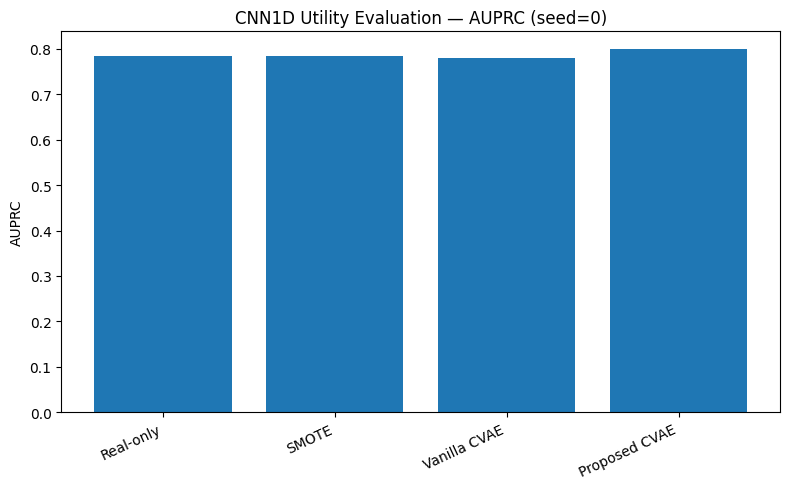

Saved: /content/drive/MyDrive/vtac_project/evaluation_true_vanilla/utility_eval_CNN1D_auprc_bar_seed0.png


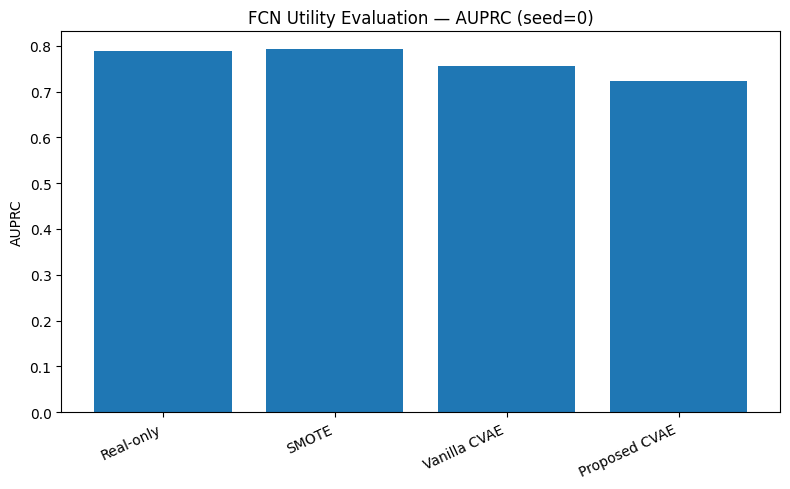

Saved: /content/drive/MyDrive/vtac_project/evaluation_true_vanilla/utility_eval_FCN_auprc_bar_seed0.png


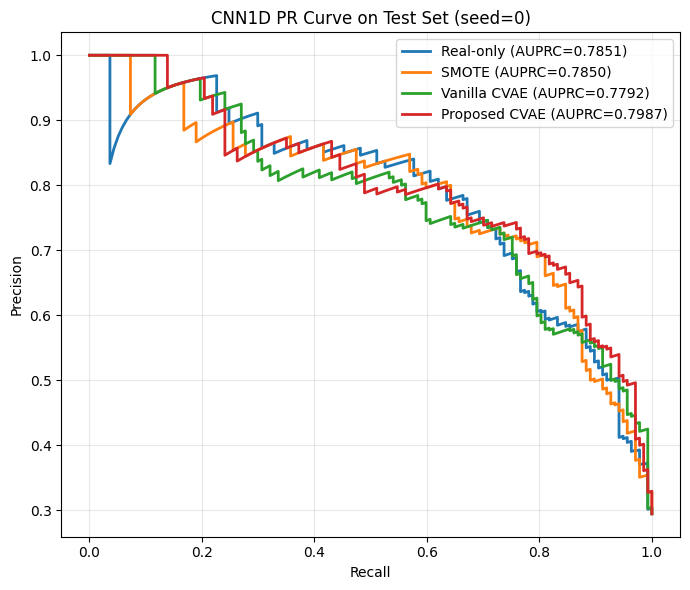

Saved: /content/drive/MyDrive/vtac_project/evaluation_true_vanilla/utility_eval_CNN1D_pr_curve_seed0.png


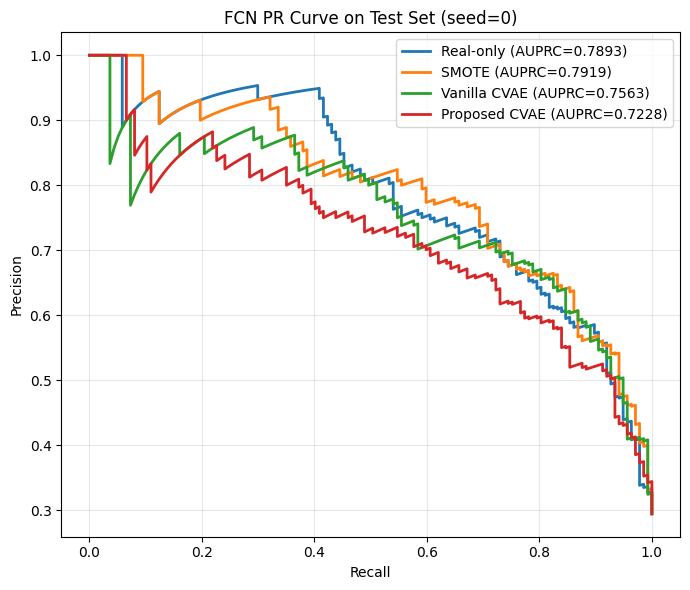

Saved: /content/drive/MyDrive/vtac_project/evaluation_true_vanilla/utility_eval_FCN_pr_curve_seed0.png


In [13]:
# ============================================================
# 12. Plots: AUPRC bars and PR curves for first seed
# ============================================================

plot_seed = EVAL_SEEDS[0]

for clf_name in ["CNN1D", "FCN"]:
    sub = raw_df[(raw_df["Classifier"] == clf_name) & (raw_df["Seed"] == plot_seed)].copy()
    sub["method_order"] = sub["Training Data"].map({"Real-only": 0, "SMOTE": 1, "Vanilla CVAE": 2, "Proposed CVAE": 3})
    sub = sub.sort_values("method_order")

    plt.figure(figsize=(8, 5))
    plt.bar(sub["Training Data"], sub["AUPRC"])
    plt.ylabel("AUPRC")
    plt.title(f"{clf_name} Utility Evaluation — AUPRC (seed={plot_seed})")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()

    fig_path = os.path.join(EVAL_OUT_DIR, f"utility_eval_{clf_name}_auprc_bar_seed{plot_seed}.png")
    plt.savefig(fig_path, dpi=200)
    plt.show()
    print("Saved:", fig_path)


for clf_name in ["CNN1D", "FCN"]:
    plt.figure(figsize=(7, 6))

    for r in all_results:
        if r["Classifier"] == clf_name and r["Seed"] == plot_seed:
            plt.plot(
                r["recall_curve"],
                r["precision_curve"],
                linewidth=2,
                label=f"{r['Training Data']} (AUPRC={r['AUPRC']:.4f})",
            )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{clf_name} PR Curve on Test Set (seed={plot_seed})")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    fig_path = os.path.join(EVAL_OUT_DIR, f"utility_eval_{clf_name}_pr_curve_seed{plot_seed}.png")
    plt.savefig(fig_path, dpi=200)
    plt.show()
    print("Saved:", fig_path)

## Reporting note

Use **AUPRC as the primary metric**, because true VT alarms are the minority class.

The SMOTE row is a **non-generative flattened-waveform oversampling baseline**. It is included for controlled utility comparison, not as a physiologically realistic waveform generator.

The **Vanilla CVAE** row in this fixed notebook means: single-encoder conditional VAE with masked reconstruction MSE + KL only. It excludes wavelet/STFT loss, ECG-pulse/correlation loss, classifier/perceptual loss, attention, and multi-branch fusion.

For the report, state the augmentation ratio explicitly using the generated `utility_eval_augmentation_ratios.csv`; with the common split this is usually:

- Real training set: true = 1,147, false = 2,754
- Synthetic true samples: 1,607
- Augmented training set: true = 2,754, false = 2,754
- Final true:false ratio = 1:1
- Synthetic / real true = 1.40×
